In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'
print(f'TensorLy backend: {tl.get_backend()}')

TensorLy backend: numpy


In [3]:
from moabb.datasets import *
from notebooks.data_loader import load_moabb_p300

epochs, labels, meta = load_moabb_p300(Lee2019_ERP, subjects=[1], session=0)
epochs

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 1980 events (all good), 0 – 1 s (baseline off), ~937.6 MB, data loaded,
 'Target': 330
 'NonTarget': 1650>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 2160 events (all good), 0 – 1 s (baseline off), ~1022.8 MB, data loaded,
 'Target': 360
 'NonTarget': 1800>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 1980 events (all good), 0 – 1 s (baseline off), ~937.6 MB, data loaded,
 'Target': 330
 'NonTarget': 1650>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 2160 events (all good), 0 – 1 s (baseline off), ~1022.8 MB, data lo

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
8280 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning:

Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.



<EpochsArray | 4140 events (all good), 0 – 0.979 s (baseline off), ~94.1 MB, data loaded, with metadata,
 'Target': 690
 'NonTarget': 3450>

No projector specified for this dataset. Please consider the method self.add_proj.


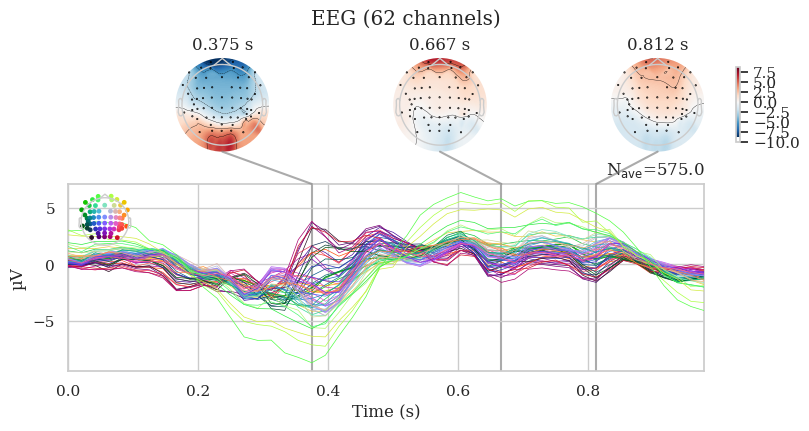

In [4]:
from mne import combine_evoked

contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])
contrast.plot_joint();

In [5]:
from notebooks.data_loader import postprocess
from hoda.tensorize import hankel_tensor

X,y = postprocess(epochs, labels, zscore=True)
X = hankel_tensor(X)
X.shape

(4140, 62, 25, 24)

In [6]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=64,
        tol=1e-6,
        shrinkage='lw',
        obj='tr',
        solver='lanczos',
        toeplitz=None,
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        theta=0.8,
        forward=True       
)


In [7]:
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

%load_ext line_profiler
%lprun -f hoda.fit_backward hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

Backward HODA model rank=(1, 7, 7): 100%|██████████| 64/64 [01:39<00:00,  1.56s/it]
/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/hoda.py:354: UserWarning:

Maximum number of iterations reached without convergence



Timer unit: 1e-09 s

Total time: 111.815 s
File: /vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/hoda.py
Function: fit_backward at line 180

Line #      Hits         Time  Per Hit   % Time  Line Contents
   180                                               def fit_backward(
   181                                                   self,
   182                                                   X,
   183                                                   y,
   184                                                   X_centered=None,
   185                                                   means=None,
   186                                                   classes=None,
   187                                                   class_counts=None,
   188                                               ):
   189         1      19212.0  19212.0      0.0          self._validate(X, y)
   190                                           
   191                                                  

In [9]:
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.053940,0.000240,3.018518e+07
1,1,2,2,1.226554,0.001702,7.747611e+07
2,1,3,3,1.353451,0.002078,4.759014e+07
3,2,1,4,0.404659,0.001169,7.543964e+06
4,2,2,5,1.424381,0.003075,5.344621e+07
...,...,...,...,...,...,...
187,63,2,188,0.001001,0.002261,3.346243e+07
188,63,3,189,0.001043,0.001492,2.690198e+07
189,64,1,190,0.000130,0.003205,1.623642e+05
190,64,2,191,0.000968,0.002260,3.345712e+07


In [10]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


In [11]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()


In [12]:

px.line(df, x='flip', y='update', log_y=True, color='mode')


In [13]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [14]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [15]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model : 100%|██████████| 63/63 [03:32<00:00,  3.37s/it]


,iteration,mode,flip,update,shrinkage
0,1,1,1,4.213896,0.000000e+00
1,1,2,2,2.226070,3.749250e-06
2,1,3,3,3.757304,1.250626e-06
3,2,1,4,0.762247,0.000000e+00
4,2,2,5,1.722109,1.608724e-06
...,...,...,...,...,...
184,62,2,185,0.000062,9.461945e-07
185,62,3,186,0.000056,1.145910e-06
186,63,1,187,0.000005,0.000000e+00
187,63,2,188,0.000054,9.461717e-07


In [16]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [17]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

In [18]:
px.line(df, x='flip', y='shrinkage', log_y=True, color='mode')

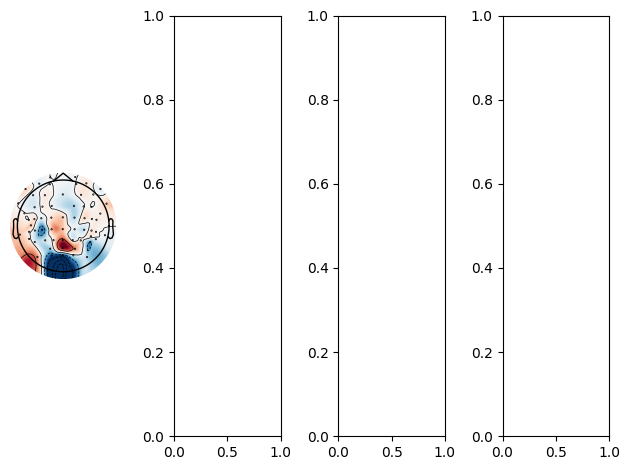

In [19]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [20]:
from mne.viz import plot_topomap
from plotly.tools import mpl_to_plotly

# TODO spatial weights
df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='weight')
px.line(df, x='time', y='weight', facet_col='rank', facet_col_wrap=4)

ValueError: Length of values (48) does not match length of index (25)

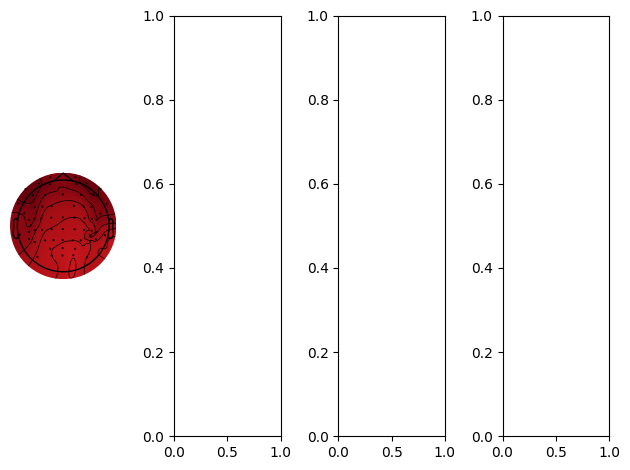

In [21]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])


In [22]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='amplitude')
px.line(df, x='time', y='amplitude', facet_col='rank', facet_col_wrap=4)

ValueError: Length of values (48) does not match length of index (25)

In [23]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np
from sklearn.preprocessing import StandardScaler

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))
xt = StandardScaler().fit_transform(xt)

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,1960.508222,0.000000e+00,True
1,1,0.002062,9.637799e-01,False
2,2,7.251601,7.112331e-03,True
3,3,0.670073,4.130732e-01,False
4,4,0.278684,5.975934e-01,False
5,5,2.930961,8.697068e-02,False
6,6,0.205965,6.499720e-01,False
7,7,28.363885,1.058625e-07,True
8,8,2.590283,1.075974e-01,False
9,9,0.119723,7.293524e-01,False


In [24]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [25]:
from sklearn.manifold import TSNE

x_viz = TSNE(n_components=2).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)

In [26]:
from sklearn.metrics import get_scorer

scorer = get_scorer(paradigm.scoring)
scorer([0,1],[0,1])

NameError: name 'paradigm' is not defined